In [1]:
library(SingleCellExperiment)
library(data.table)
library(Matrix)
library(Seurat)
library(dplyr)
library(purrr)
library(stringr)

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges

In [2]:
# input output list
io = list()

# my rds home directory
io$home = '/rds/project/rds-SDzz0CATGms/users/bt392/'

# directory where the data 10x cellranger output is stored
io$datadir = sprintf('%s/09_Eomes_invitro_blood/original/', io$home)

In [3]:
# names of sample folders
samples = c('rv_eo_deg_day3_5_control','rv_eo_deg_day4_control')

In [4]:
# we first make a list of matrices containing every sample in the list of samples:
matrix_list = lapply(samples, function(sample){ 
        a = Sys.time()

        # sample specific input folder
        data_tmp = sprintf('%s/%s/outs/filtered_feature_bc_matrix/', io$datadir, sample)
        # load barcodes, features, and matrix object
        barcodes = fread(sprintf('%s/barcodes.tsv.gz', data_tmp), header = F)
        features = fread(sprintf('%s/features.tsv.gz', data_tmp))
        matrix = readMM(gzfile((sprintf('%s/matrix.mtx.gz', data_tmp))))
        
        # annotate the row and column names of the matrix using the features and barcodes
        rownames(matrix) = features$V2
        colnames(matrix) = paste0(sample, '#', barcodes$V1) # this makes the cell names sample specific (sample, #, barcode)

        # only keep the rows that belong to gene expression (excludes the ATAC matrix)
        matrix = matrix[features[V3 == 'Gene Expression', V2], ]
    
        # make the gene names unique
        rownames(matrix) = make.names(rownames(matrix), unique = T)
        return(matrix)
        
        b = Sys.time()
        print(b-a)
})

In [5]:
# combine the matrices into one big matrix containing all samples
matrix_combined = do.call('cbind', matrix_list)
dim(matrix_combined)

# 5206 cells with 32285 genes

[1] 32285  5010

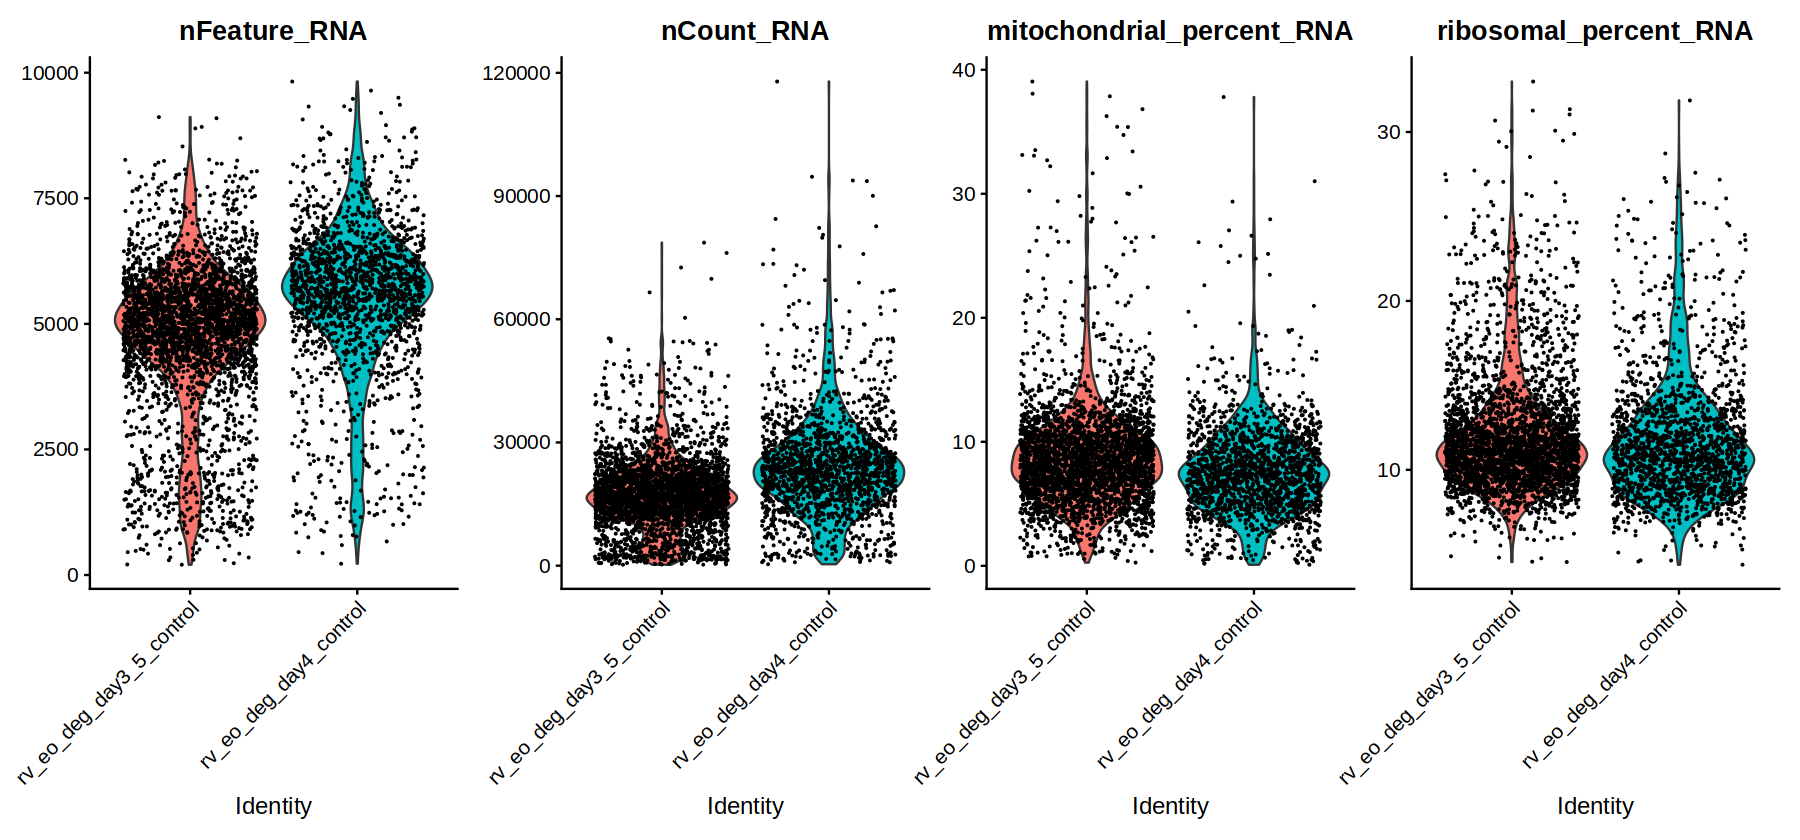

In [6]:
## This is the standard seurat pipeline:

# Create seurat object
pbmc <- CreateSeuratObject(counts = matrix_combined, project = "pbmc3k", min.cells = 3, min.features = 200)

# Add sample information into Seurat object based on cell name
pbmc@meta.data$orig.idents = str_split(rownames(pbmc@meta.data), "#") %>% map_chr(1)
Idents(pbmc) = pbmc@meta.data$orig.idents

# Add mitochondrial percentage
pbmc[["mitochondrial_percent_RNA"]] <- PercentageFeatureSet(pbmc, pattern = "^mt") %>% round(2)

# Add ribosomal RNA percentage
ribo.genes <- grep(pattern = "^Rp[l|s]", x = rownames(pbmc), value = TRUE)
pbmc[["ribosomal_percent_RNA"]] <- PercentageFeatureSet(pbmc, features = ribo.genes) %>% round(2)

# Visualize QC metrics as a violin plot
options(repr.plot.width = 15, repr.plot.height = 7)
VlnPlot(pbmc, features = c("nFeature_RNA", "nCount_RNA", "mitochondrial_percent_RNA", "ribosomal_percent_RNA"), ncol = 4)

In [7]:
# perform quality control based on the distributions in the violin plots
# Change the values here depending on your own data!
pbmc <- subset(pbmc, subset = nFeature_RNA > 2000 & nCount_RNA > 300 & nCount_RNA < 50000 & mitochondrial_percent_RNA < 15)

# Normalize data 
pbmc <- NormalizeData(pbmc, normalization.method = "LogNormalize", scale.factor = 10000)

# Find most variable features (used for dimensionality reduction)
pbmc <- FindVariableFeatures(pbmc, selection.method = "vst", nfeatures = 4000)

# scale data so that mean expression per gene is 0 and the standard deviation is 1
all.genes <- rownames(pbmc)
pbmc <- ScaleData(pbmc, features = all.genes)

# perform PCA
pbmc <- RunPCA(pbmc, features = VariableFeatures(object = pbmc))

# Clustering
pbmc <- FindNeighbors(pbmc, dims = 1:15)
pbmc <- FindClusters(pbmc, resolution = 0.7)

# UMAP
pbmc <- RunUMAP(pbmc, dims = 1:15, verbose = F)

# Add log10 read count and feature count informatino
pbmc@meta.data$logcount = log10(pbmc@meta.data$nCount_RNA)
pbmc@meta.data$logfeature = log10(pbmc@meta.data$nFeature_RNA)


Centering and scaling data matrix

PC_ 1 
Positive:  Fst, Tdgf1, Mesp1, Lef1, Sulf1, Cachd1, T, Dennd2c, Pid1, Itpr1 
	   Gpc3, Pcmtd1, Ptprk, Pde4d, Igfbp3, Wnt3, Dll3, Chst7, Eomes, Fgf8 
	   Smc6, Dock11, Cdh2, Rftn1, Lhx1, Tenm3, Ppp4r4, Bmper, Klhl32, Plxna2 
Negative:  Igf2, Fli1, Tek, F2r, Vav3, Egfl7, Ramp2, Flt1, Tspan18, Rapgef5 
	   Col4a2, Csgalnact1, Prkar2b, Hapln1, Adgra2, Col4a1, Fbn1, Arap3, Fbn2, Gadd45g 
	   Bmp6, Plxnd1, Cdh5, Rasip1, Edil3, Cbfa2t3, Arhgap31, Skap1, Cgnl1, Pecam1 
PC_ 2 
Positive:  Cdh1, Cldn7, Plekha7, Aff1, Bst2, Magi2, Esrp1, Cldn6, Nfasc, Igfbp2 
	   X1700019D03Rik, Xkr4, Nrcam, Epcam, Fgf8, Lrba, Ldb2, Lncpint, Rims2, Map7 
	   Rev1, Iqgap2, Tdrd5, Tpd52, Slc1a3, F2rl1, Igfbp3, Kcnh8, Prrg4, Wfdc2 
Negative:  Slc38a4, Prdm6, Cdh11, Amot, Prtg, Hmga2, Unc5c, Tbx20, Pmp22, Tbx3 
	   Fbln2, Tmem88, Igsf3, Gpc3, Sgms1, Wnt5a, Ppic, Bambi, Braf, Kif26b 
	   Rbms1, Plac1, Zfp516, Peg10, Bmp4, Ptpn13, Hs3st3b1, Nrp1, Foxf1, Cdh2 
PC_ 3 
Positive:  Gp

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4422
Number of edges: 144043

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8220
Number of communities: 9
Elapsed time: 0 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


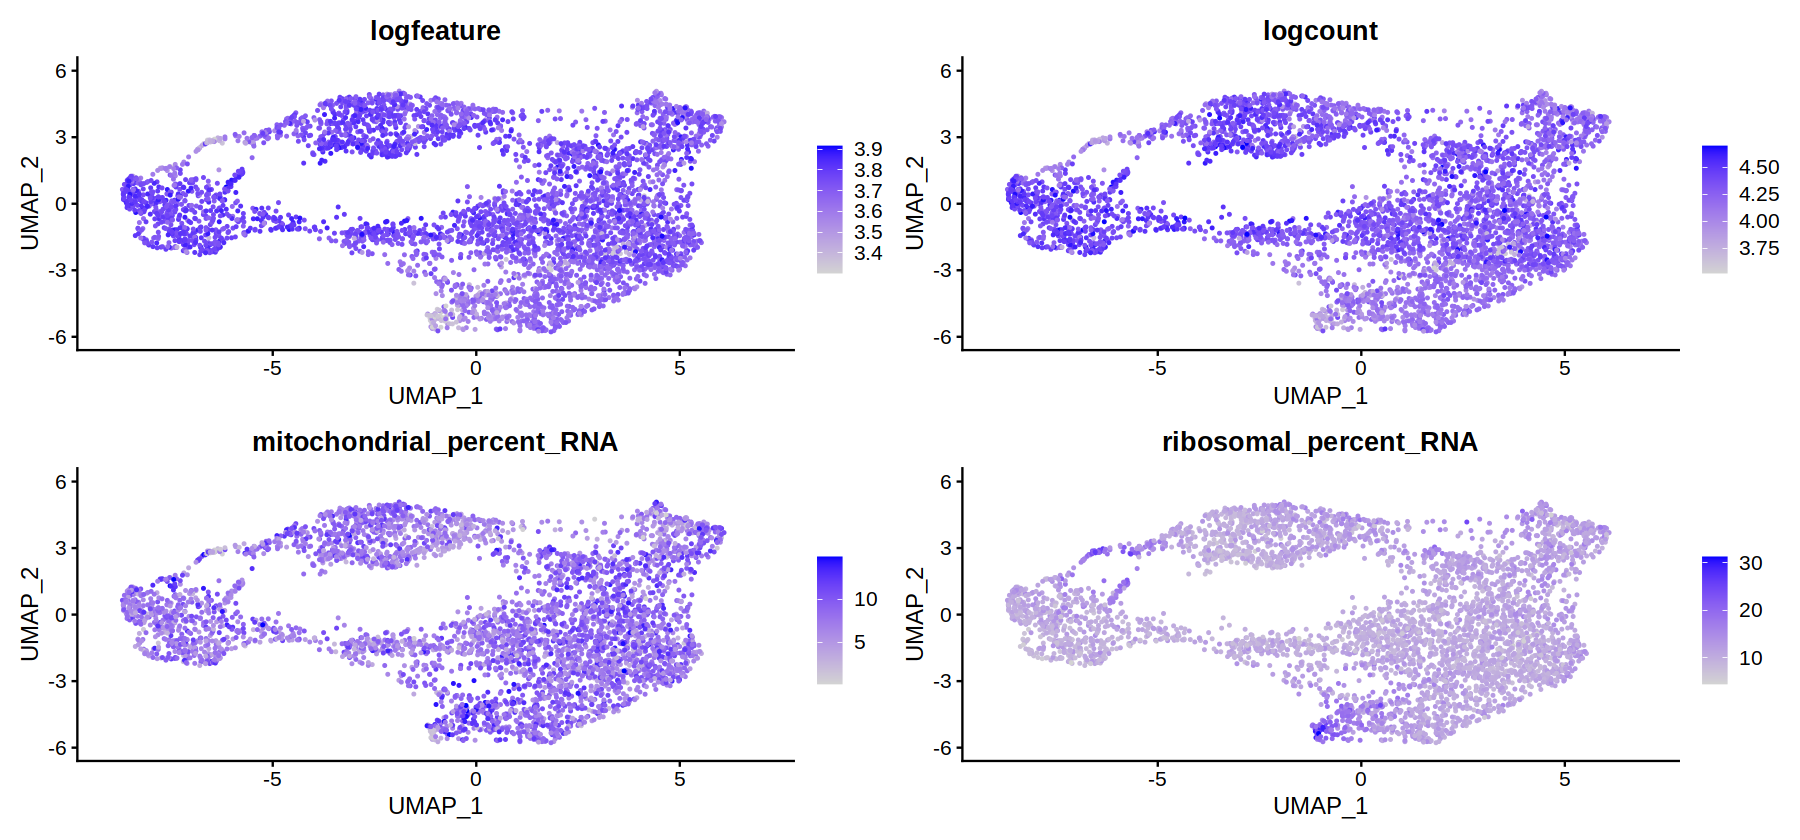

In [8]:
FeaturePlot(
  pbmc,
  c("logfeature", "logcount", "mitochondrial_percent_RNA", 'ribosomal_percent_RNA'))

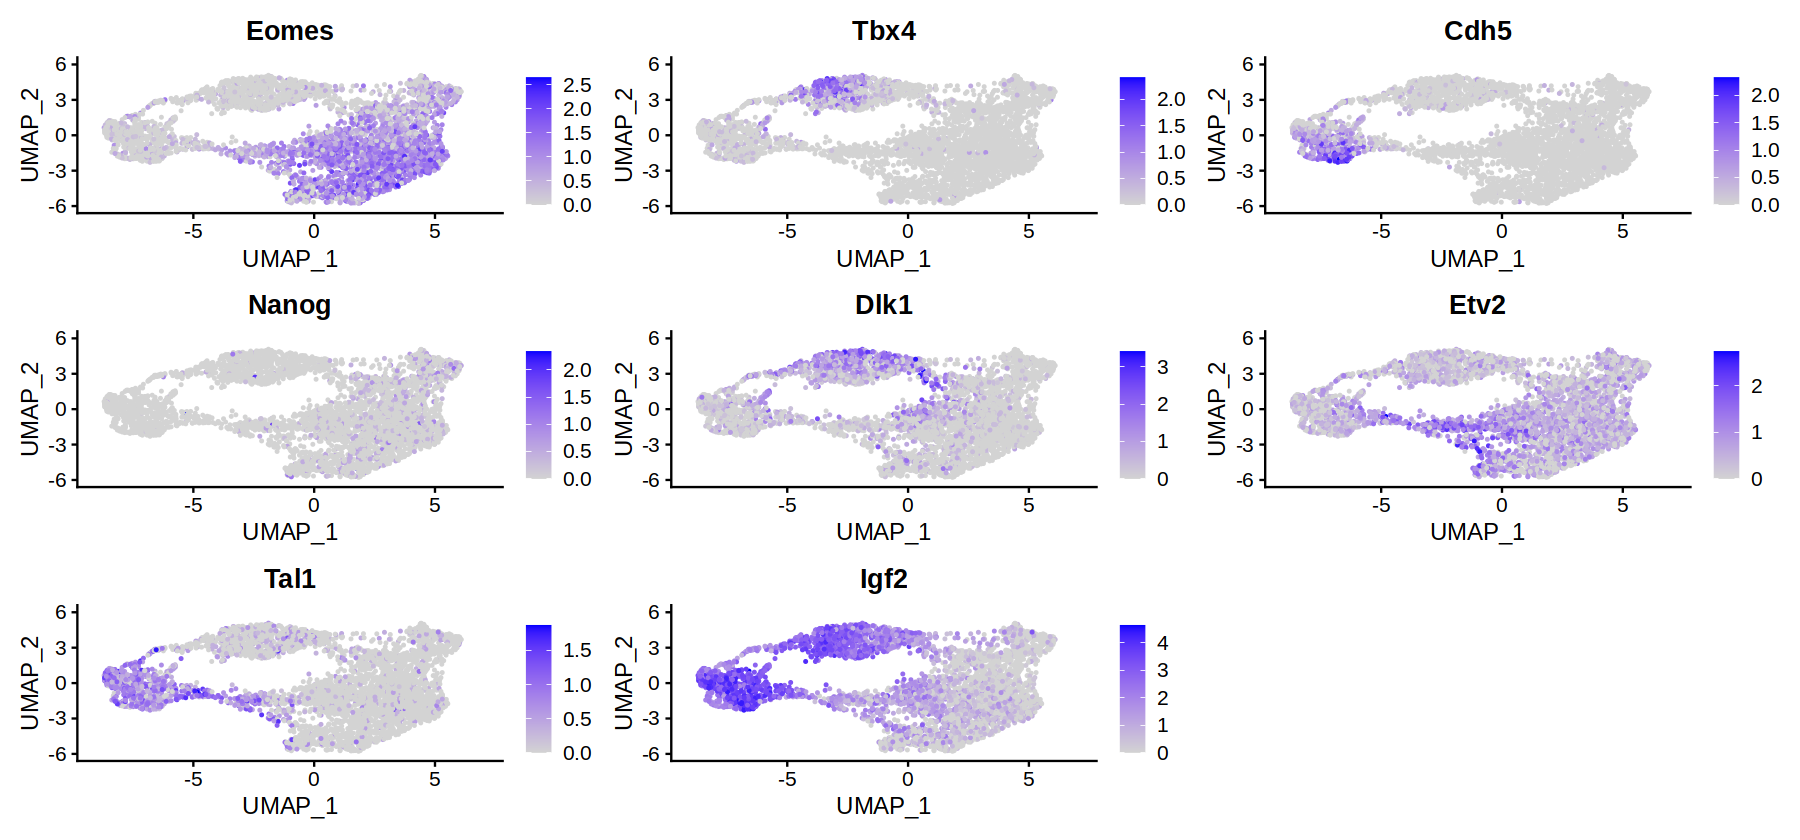

In [9]:
FeaturePlot(
  pbmc,
  c('Eomes', 'Tbx4', 'Cdh5', 'Nanog', 'Dlk1', 'Etv2', 'Tal1', 'Igf2'))

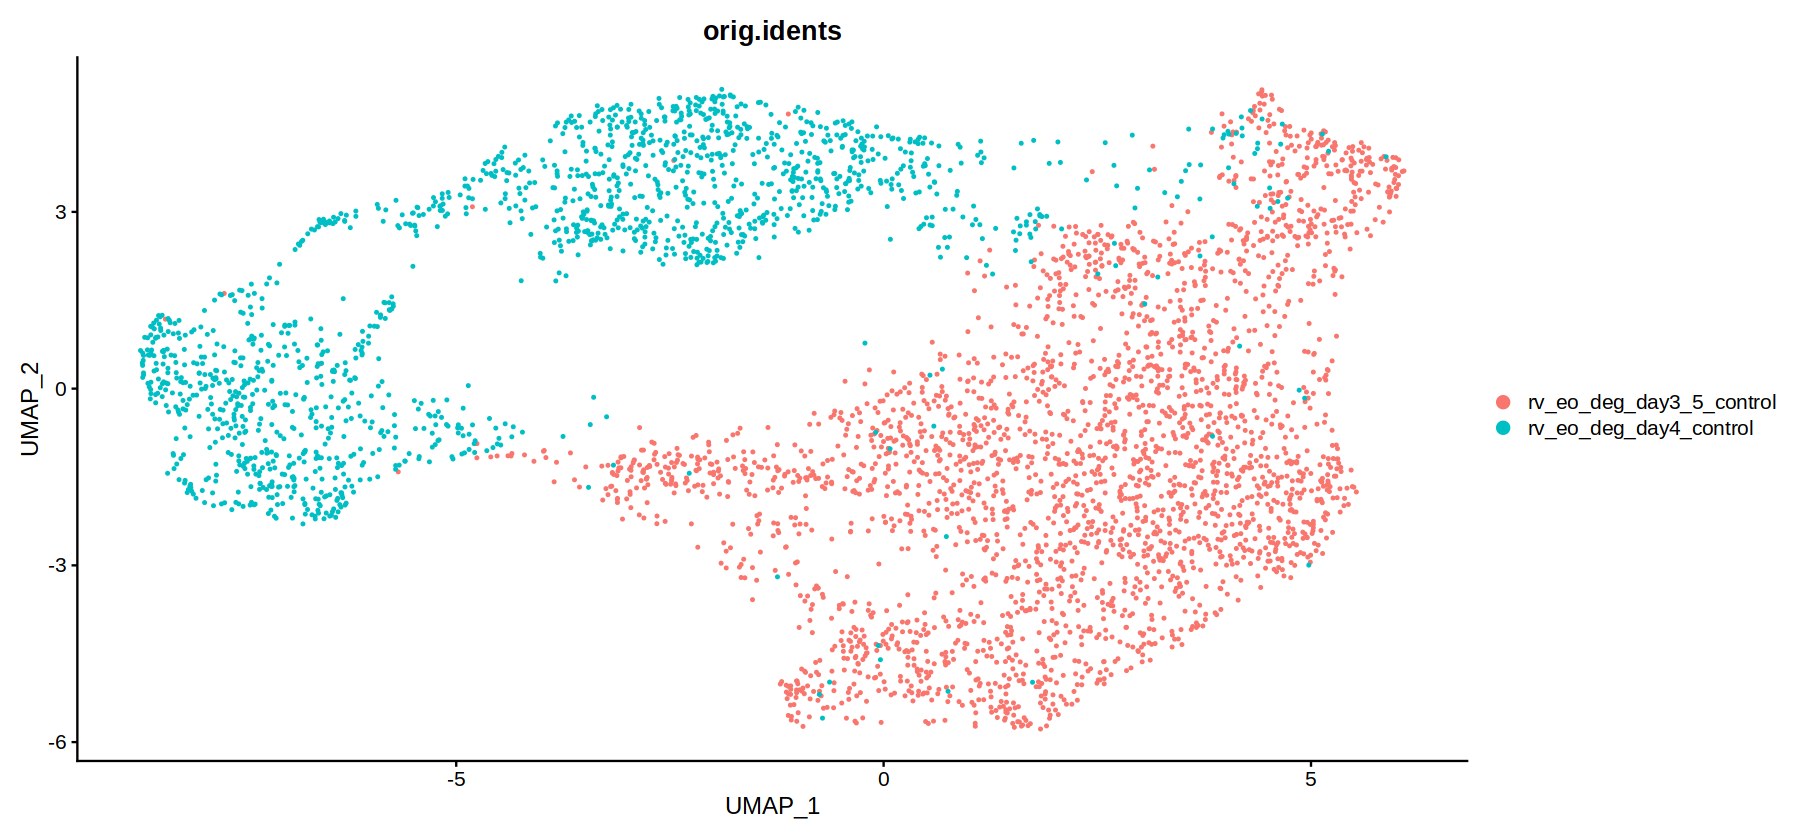

In [10]:
DimPlot(pbmc, reduction = "umap", group.by = 'orig.idents')

You can see there are quite strong batch effects between the samples, so in this case you want to correct for this using some batch correction method, like found here: 

https://satijalab.org/seurat/articles/seurat5_integration

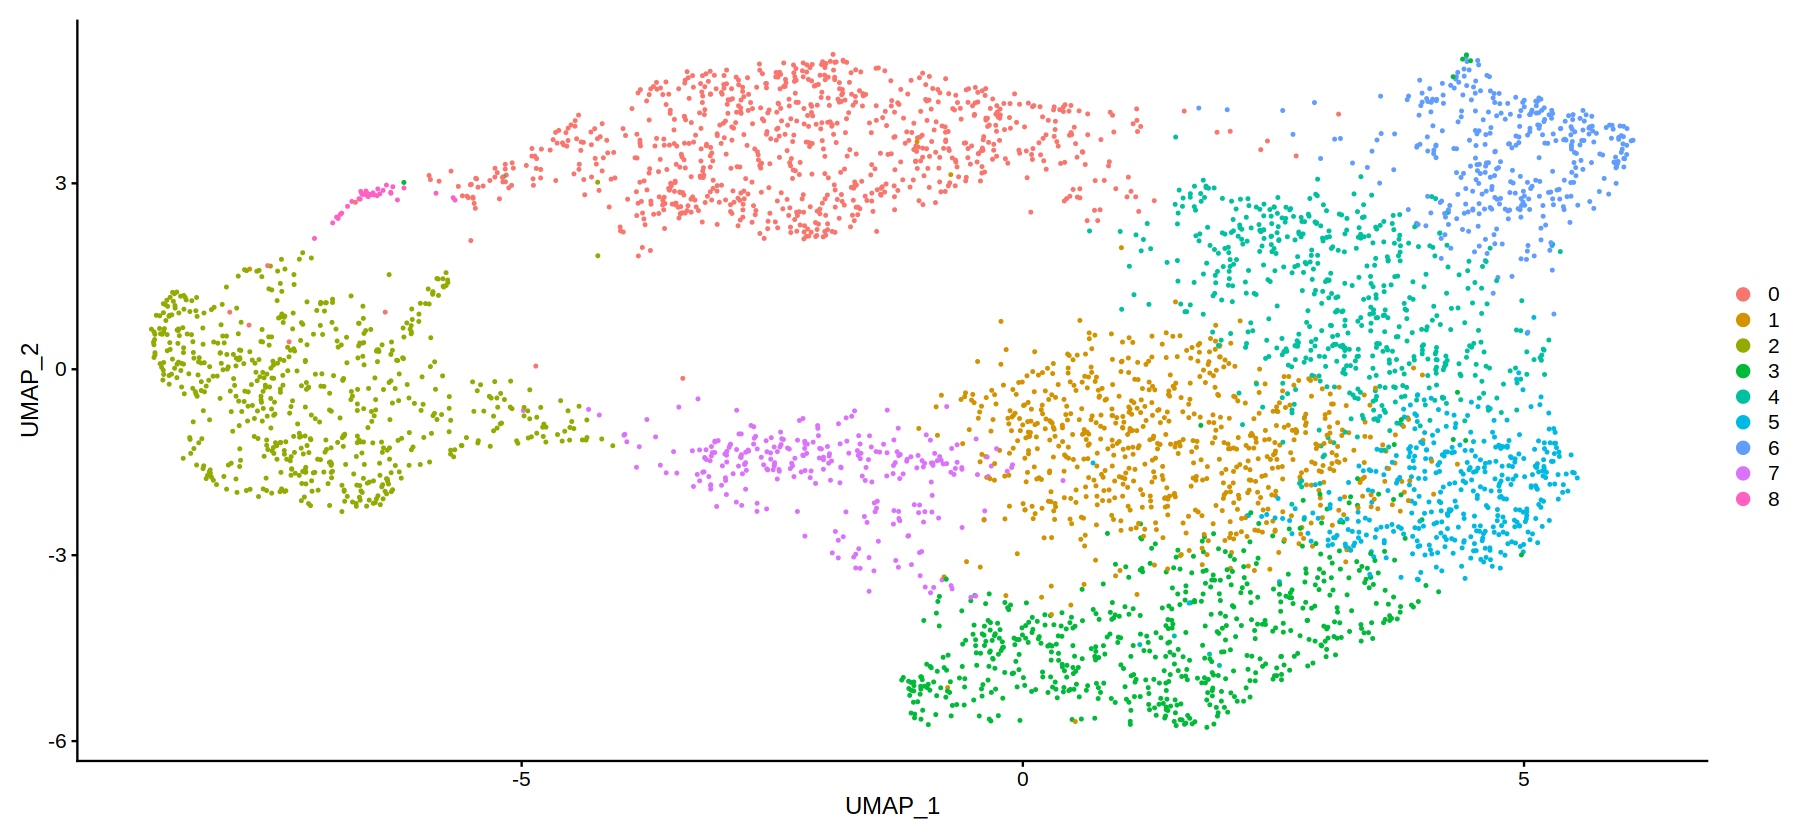

In [11]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters
DimPlot(pbmc, reduction = "umap")

In [12]:
# find markers for every cluster compared to all remaining cells, report only the positive
# ones
pbmc.markers <- FindAllMarkers(pbmc, only.pos = TRUE)
pbmc.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8



p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
0.000000e+00,2.157530,0.994,0.647,0.000000e+00,0,Unc5c
0.000000e+00,1.723062,0.708,0.115,0.000000e+00,0,Col1a1
1.811924e-291,1.509653,0.829,0.255,4.152748e-287,0,Car4
2.020743e-283,1.453434,0.955,0.490,4.631342e-279,0,Tbx20
2.180759e-278,1.143479,0.746,0.178,4.998081e-274,0,Ahnak
2.866145e-265,1.848901,0.908,0.474,6.568918e-261,0,Airn
1.961452e-253,1.260791,0.998,0.976,4.495452e-249,0,Slc38a4
4.332522e-249,1.033081,0.996,0.805,9.929707e-245,0,Hand1
9.752471e-234,1.083724,0.968,0.657,2.235169e-229,0,Zfp516


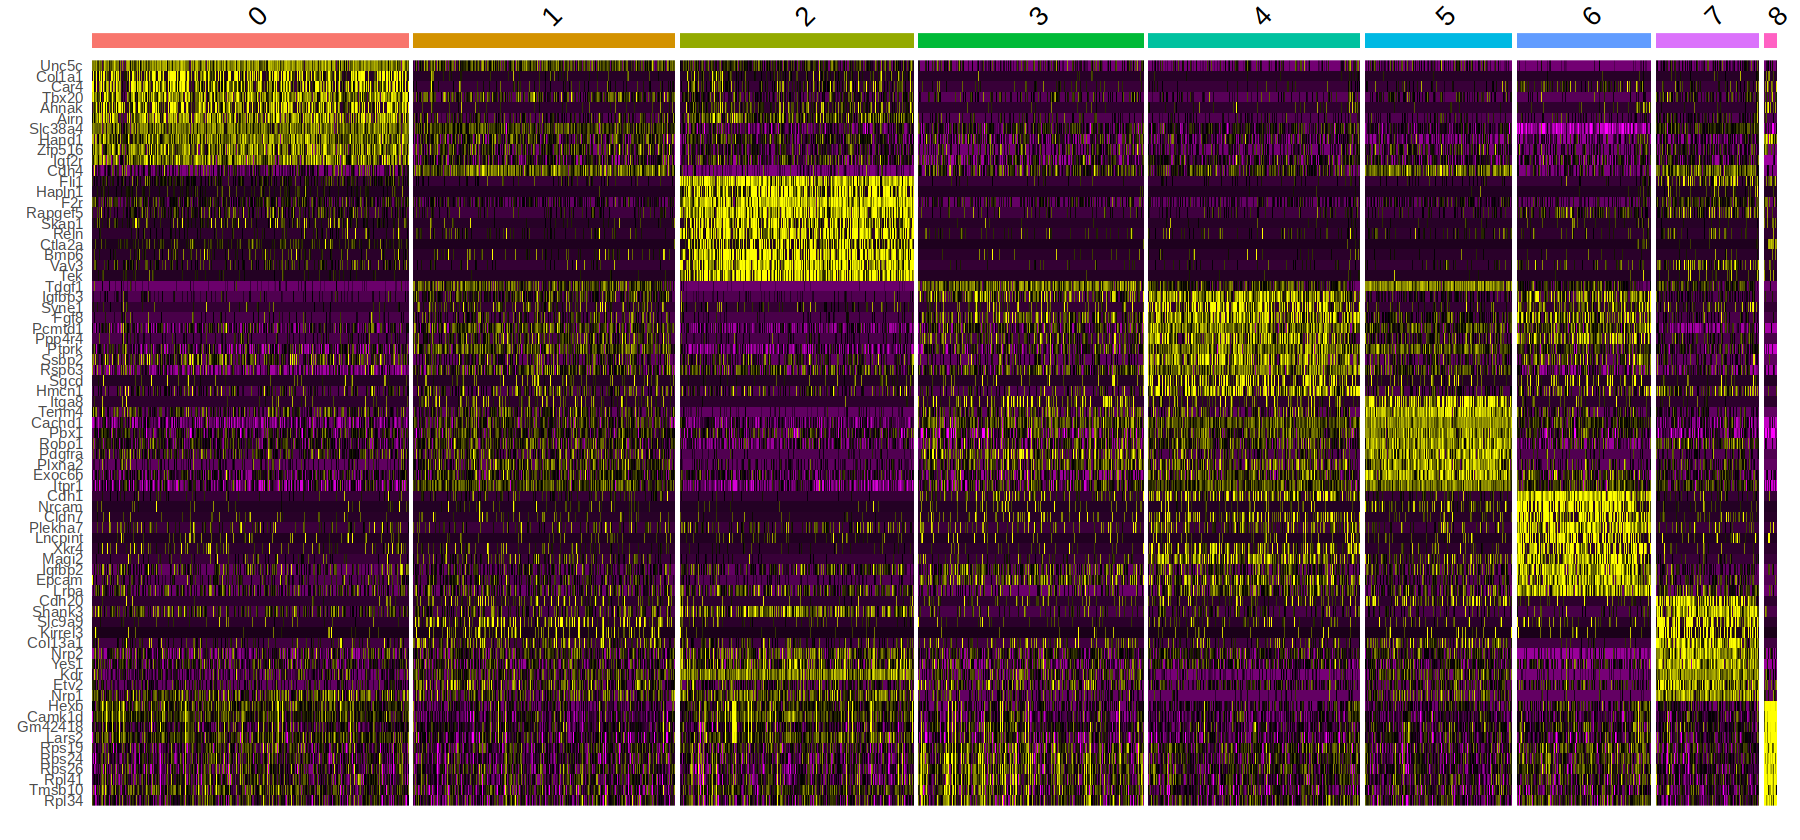

In [13]:
pbmc.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1) %>%
    slice_head(n = 10) %>%
    ungroup() -> top10
DoHeatmap(pbmc, features = top10$gene) + NoLegend()